# Assignment 3 — IoT Sensor Data Analysis

Analyze IoT sensor readings from manufacturing devices to identify abnormal operating conditions, machine health, and maintenance priorities.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Locate the repository/assignment data folder
for candidate in (Path.cwd(), Path.cwd().parent, Path.cwd() / "Day 4" / "Assignment 3"):
    if (candidate / "data").exists():
        BASE = candidate
        break
else:
    raise FileNotFoundError("Run this notebook from the repository or assignment folder.")

DATA = BASE / "data"
OUTPUT = BASE / "output"
OUTPUT.mkdir(exist_ok=True)

df = pd.read_csv(DATA / "iot_sensor_data_raw.csv")
print("Dataset loaded successfully")
print("Shape:", df.shape)
display(df.head())

Dataset loaded successfully
Shape: (20000, 9)


,Timestamp,Device_ID,Temperature,Humidity,Pressure,Vibration,Battery_Level,Location,Machine_Status
0,2026-04-21 22:30:00,DEV_005,65.89,62.70,1007.96,2.22,46.51,Factory_A,Warning
1,2026-01-22 06:15:00,DEV_007,70.65,70.95,1021.85,2.73,57.04,Factory_A,Normal
2,2026-04-01 07:00:00,DEV_005,81.01,60.49,1009.82,2.15,11.65,Factory_A,Normal
3,2026-01-12 14:30:00,DEV_007,74.17,68.76,1001.42,2.03,17.36,Factory_C,Critical
4,2026-05-25 19:30:00,DEV_008,74.04,54.32,1014.34,NaN,27.04,Factory_C,Normal


## Part A — Data Preparation

In [2]:
# 2. Display dimensions and structure
print("Dimensions:", df.shape)
print("\nStructure and data types:")
df.info()

# 3. Convert Timestamp into Pandas datetime
df["Timestamp"] = pd.to_datetime(df["Timestamp"], errors="coerce")
print("\nInvalid timestamps:", df["Timestamp"].isna().sum())

# 4. Check whether timestamps are correctly ordered
timestamps_ordered = df["Timestamp"].is_monotonic_increasing
print("Timestamps already ordered:", timestamps_ordered)

# Sort chronologically for time-series analysis
df = df.sort_values("Timestamp").reset_index(drop=True)

# 5 & 6. Missing readings and missing-value percentage
sensor_columns = ["Temperature", "Humidity", "Pressure", "Vibration", "Battery_Level"]
missing_counts = df[sensor_columns].isna().sum()
missing_percentage = (df[sensor_columns].isna().mean() * 100).round(2)

missing_summary = pd.DataFrame({
    "Missing_Count": missing_counts,
    "Missing_Percentage": missing_percentage
})

print("\nMissing sensor readings:")
display(missing_summary)

Dimensions: (20000, 9)

Structure and data types:
<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Timestamp       20000 non-null  str    
 1   Device_ID       20000 non-null  str    
 2   Temperature     19701 non-null  float64
 3   Humidity        19700 non-null  float64
 4   Pressure        19700 non-null  float64
 5   Vibration       19702 non-null  float64
 6   Battery_Level   20000 non-null  float64
 7   Location        20000 non-null  str    
 8   Machine_Status  20000 non-null  str    
dtypes: float64(5), str(4)
memory usage: 1.4 MB

Invalid timestamps: 0
Timestamps already ordered: False

Missing sensor readings:


,Missing_Count,Missing_Percentage
Temperature,299,1.50
Humidity,300,1.50
Pressure,300,1.50
Vibration,298,1.49
Battery_Level,0,0.00


## Part B — Data Cleaning and Abnormal Conditions

In [3]:
# 7. Handle missing sensor values
# Median imputation is used because sensor data can contain outliers,
# and the median is less sensitive to extreme values than the mean.
df[sensor_columns] = (
    df.groupby("Device_ID")[sensor_columns]
      .transform(lambda x: x.fillna(x.median()))
)

# If an entire device column is missing, use the overall sensor median.
df[sensor_columns] = df[sensor_columns].fillna(df[sensor_columns].median())

print("Remaining missing sensor values:")
print(df[sensor_columns].isna().sum())

# 8. Identify abnormal temperature readings
# 9. Identify abnormal vibration readings
TEMPERATURE_WARNING = 70
TEMPERATURE_CRITICAL = 80
VIBRATION_WARNING = 3
VIBRATION_CRITICAL = 5
BATTERY_CRITICAL = 20

abnormal_temperature = df[df["Temperature"] >= TEMPERATURE_WARNING]
abnormal_vibration = df[df["Vibration"] >= VIBRATION_WARNING]
critical_battery = df[df["Battery_Level"] < BATTERY_CRITICAL]

print("Abnormal temperature readings:", len(abnormal_temperature))
display(abnormal_temperature.head(10))

print("Abnormal vibration readings:", len(abnormal_vibration))
display(abnormal_vibration.head(10))

# 10. Machines with critically low battery
critical_battery_devices = df.loc[df["Battery_Level"] < BATTERY_CRITICAL, "Device_ID"].unique()
print("Devices with critically low battery:", critical_battery_devices)

# 11. Explanation of abnormal thresholds
print("\nThreshold rationale:")
print(f"Temperature: Normal < {TEMPERATURE_WARNING}°C, Warning {TEMPERATURE_WARNING}-{TEMPERATURE_CRITICAL-1}°C, Critical >= {TEMPERATURE_CRITICAL}°C")
print(f"Vibration: Normal < {VIBRATION_WARNING}, Warning {VIBRATION_WARNING}-{VIBRATION_CRITICAL-1}, Critical >= {VIBRATION_CRITICAL}")
print(f"Battery: Healthy >= 50%, Moderate 20-49%, Critical < {BATTERY_CRITICAL}%")
print("These thresholds are operational assumptions for the assignment and should be replaced by manufacturer specifications when available.")

Remaining missing sensor values:
Temperature      0
Humidity         0
Pressure         0
Vibration        0
Battery_Level    0
dtype: int64
Abnormal temperature readings: 10068


,Timestamp,Device_ID,Temperature,Humidity,Pressure,Vibration,Battery_Level,Location,Machine_Status
2,2026-01-01 00:30:00,DEV_005,78.07,62.70,1029.55,2.86,63.12,Factory_A,Normal
3,2026-01-01 00:45:00,DEV_007,70.26,51.49,994.29,3.20,71.38,Factory_B,Normal
4,2026-01-01 01:00:00,DEV_003,79.59,59.03,997.97,2.04,66.31,Factory_C,Normal
6,2026-01-01 01:30:00,DEV_005,79.23,66.02,1009.47,2.54,62.40,Factory_C,Warning
8,2026-01-01 02:00:00,DEV_007,74.80,53.83,998.32,2.70,85.74,Factory_B,Warning
10,2026-01-01 02:30:00,DEV_003,80.84,61.41,1022.74,2.23,52.96,Factory_B,Normal
13,2026-01-01 03:15:00,DEV_003,74.05,54.96,1004.88,1.68,43.88,Factory_A,Normal
14,2026-01-01 03:30:00,DEV_008,83.18,64.79,1018.03,3.97,88.91,Factory_C,Normal
15,2026-01-01 03:45:00,DEV_005,71.89,28.12,1009.31,2.28,22.61,Factory_B,Normal
18,2026-01-01 04:30:00,DEV_008,77.58,57.77,1034.37,3.25,78.48,Factory_C,Normal


Abnormal vibration readings: 5335


,Timestamp,Device_ID,Temperature,Humidity,Pressure,Vibration,Battery_Level,Location,Machine_Status
3,2026-01-01 00:45:00,DEV_007,70.26,51.49,994.29,3.20,71.38,Factory_B,Normal
9,2026-01-01 02:15:00,DEV_002,69.13,34.65,1012.98,3.17,49.87,Factory_A,Normal
14,2026-01-01 03:30:00,DEV_008,83.18,64.79,1018.03,3.97,88.91,Factory_C,Normal
18,2026-01-01 04:30:00,DEV_008,77.58,57.77,1034.37,3.25,78.48,Factory_C,Normal
19,2026-01-01 04:45:00,DEV_003,69.59,52.21,1032.14,3.34,42.03,Factory_B,Normal
24,2026-01-01 06:00:00,DEV_004,65.83,85.70,1001.80,3.23,11.26,Factory_B,Normal
25,2026-01-01 06:15:00,DEV_006,78.11,54.40,989.58,3.77,35.50,Factory_A,Critical
31,2026-01-01 07:45:00,DEV_001,68.71,44.80,1007.51,3.07,65.00,Factory_C,Normal
33,2026-01-01 08:15:00,DEV_002,72.22,55.88,1004.11,3.00,63.80,Factory_C,Warning
38,2026-01-01 09:30:00,DEV_001,68.14,48.11,992.61,3.04,11.78,Factory_A,Warning


Devices with critically low battery: <StringArray>
['DEV_005', 'DEV_007', 'DEV_006', 'DEV_004', 'DEV_001', 'DEV_002', 'DEV_008',
 'DEV_003']
Length: 8, dtype: str

Threshold rationale:
Temperature: Normal < 70°C, Warning 70-79°C, Critical >= 80°C
Vibration: Normal < 3, Warning 3-4, Critical >= 5
Battery: Healthy >= 50%, Moderate 20-49%, Critical < 20%
These thresholds are operational assumptions for the assignment and should be replaced by manufacturer specifications when available.


## Part C — Time-Series Analysis

In [4]:
df["Hour"] = df["Timestamp"].dt.hour

# 12. Average temperature by hour
average_temperature_by_hour = df.groupby("Hour")["Temperature"].mean().round(2)
print("Average temperature by hour:")
display(average_temperature_by_hour.to_frame("Average Temperature"))

# 13 & 14. Average temperature and vibration for each device
device_averages = df.groupby("Device_ID").agg(
    Average_Temperature=("Temperature", "mean"),
    Average_Vibration=("Vibration", "mean")
).round(2)
print("Average temperature and vibration by device:")
display(device_averages)

# 15. Maximum temperature by device
max_temperature_by_device = df.groupby("Device_ID")["Temperature"].max().round(2)

# 16. Minimum battery by device
min_battery_by_device = df.groupby("Device_ID")["Battery_Level"].min().round(2)

print("Maximum temperature by device:")
display(max_temperature_by_device.to_frame("Maximum Temperature"))

print("Minimum battery by device:")
display(min_battery_by_device.to_frame("Minimum Battery"))

# 17. Device with highest average vibration
highest_vibration_device = device_averages["Average_Vibration"].idxmax()
highest_vibration_value = device_averages.loc[highest_vibration_device, "Average_Vibration"]
print(f"Device with highest average vibration: {highest_vibration_device} ({highest_vibration_value:.2f})")

# 18. Factory with highest average temperature
factory_temperature = df.groupby("Location")["Temperature"].mean().sort_values(ascending=False)
highest_temperature_factory = factory_temperature.idxmax()
print(f"Factory with highest average temperature: {highest_temperature_factory} ({factory_temperature.max():.2f}°C)")
display(factory_temperature.to_frame("Average Temperature"))

Average temperature by hour:


,Average Temperature
Hour,
0,70.08
1,70.54
2,69.93
3,69.72
4,69.81
5,70.26
6,70.25
7,70.65
8,70.39


Average temperature and vibration by device:


,Average_Temperature,Average_Vibration
Device_ID,,
DEV_001,70.25,2.55
DEV_002,70.38,2.56
DEV_003,69.93,2.54
DEV_004,70.58,2.52
DEV_005,70.11,2.49
DEV_006,70.00,2.55
DEV_007,70.14,2.52
DEV_008,70.32,2.53


Maximum temperature by device:


,Maximum Temperature
Device_ID,
DEV_001,159.75
DEV_002,151.82
DEV_003,157.60
DEV_004,151.97
DEV_005,152.97
DEV_006,136.00
DEV_007,153.88
DEV_008,153.62


Minimum battery by device:


,Minimum Battery
Device_ID,
DEV_001,2.26
DEV_002,2.15
DEV_003,3.67
DEV_004,8.51
DEV_005,2.96
DEV_006,2.20
DEV_007,2.15
DEV_008,2.01


Device with highest average vibration: DEV_002 (2.56)
Factory with highest average temperature: Factory_C (70.27°C)


,Average Temperature
Location,
Factory_C,70.273775
Factory_A,70.228876
Factory_B,70.145349


## Part D — Create New Variables

In [5]:
# 19. Battery Status
df["Battery_Status"] = pd.cut(
    df["Battery_Level"],
    bins=[-float("inf"), 20, 50, float("inf")],
    labels=["Critical", "Moderate", "Healthy"],
    right=False
)

# 20. Temperature Status
df["Temperature_Status"] = pd.cut(
    df["Temperature"],
    bins=[-float("inf"), TEMPERATURE_WARNING, TEMPERATURE_CRITICAL, float("inf")],
    labels=["Normal", "Warning", "Critical"],
    right=False
)

# 21. Vibration Status
df["Vibration_Status"] = pd.cut(
    df["Vibration"],
    bins=[-float("inf"), VIBRATION_WARNING, VIBRATION_CRITICAL, float("inf")],
    labels=["Normal", "Warning", "Critical"],
    right=False
)

# 22. Overall Machine Health
df["Machine_Health"] = "Normal"

warning = (
    (df["Temperature_Status"] == "Warning") |
    (df["Vibration_Status"] == "Warning") |
    (df["Battery_Status"] == "Moderate")
)

critical = (
    (df["Temperature_Status"] == "Critical") |
    (df["Vibration_Status"] == "Critical") |
    (df["Battery_Status"] == "Critical")
)

df.loc[warning, "Machine_Health"] = "Warning"
df.loc[critical, "Machine_Health"] = "Critical"

print("Machine health distribution:")
display(df["Machine_Health"].value_counts())
display(df[["Device_ID", "Battery_Status", "Temperature_Status", "Vibration_Status", "Machine_Health"]].head(10))

Machine health distribution:


Machine_Health
Warning     11870
Critical     4201
Normal       3929
Name: count, dtype: int64

,Device_ID,Battery_Status,Temperature_Status,Vibration_Status,Machine_Health
0,DEV_007,Healthy,Normal,Normal,Normal
1,DEV_004,Healthy,Normal,Normal,Normal
2,DEV_005,Healthy,Warning,Normal,Warning
3,DEV_007,Healthy,Warning,Warning,Warning
4,DEV_003,Healthy,Warning,Normal,Warning
5,DEV_008,Moderate,Normal,Normal,Warning
6,DEV_005,Healthy,Warning,Normal,Warning
7,DEV_005,Critical,Normal,Normal,Critical
8,DEV_007,Healthy,Warning,Normal,Warning
9,DEV_002,Moderate,Normal,Warning,Warning


## Part E — Advanced Analysis

In [6]:
# 23. Devices that experienced critical conditions more than five times
critical_counts = (
    df[df["Machine_Health"] == "Critical"]
      .groupby("Device_ID")
      .size()
      .sort_values(ascending=False)
)
critical_devices_over_5 = critical_counts[critical_counts > 5]
print("Devices with more than five critical conditions:")
display(critical_devices_over_5.to_frame("Critical Conditions"))

# 24. Factory with the highest number of abnormal sensor readings
abnormal_mask = (
    (df["Temperature_Status"] != "Normal") |
    (df["Vibration_Status"] != "Normal") |
    (df["Battery_Status"] != "Healthy")
)

abnormal_by_factory = (
    df.loc[abnormal_mask]
      .groupby("Location")
      .size()
      .sort_values(ascending=False)
)
print("Abnormal sensor readings by factory:")
display(abnormal_by_factory.to_frame("Abnormal Readings"))
print("Factory with highest abnormal readings:", abnormal_by_factory.idxmax())

# 25. Percentage of time each device operates under warning/critical conditions
device_risk = (
    df.assign(At_Risk=df["Machine_Health"].isin(["Warning", "Critical"]))
      .groupby("Device_ID")["At_Risk"]
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)
print("Percentage of time under Warning/Critical conditions:")
display(device_risk.to_frame("At_Risk_Percentage"))

# 26. Maintenance priority
# Priority score combines critical events, at-risk operating time,
# average vibration, and minimum battery level.
maintenance = df.groupby("Device_ID").agg(
    Critical_Events=("Machine_Health", lambda x: (x == "Critical").sum()),
    At_Risk_Percentage=("Machine_Health", lambda x: x.isin(["Warning", "Critical"]).mean() * 100),
    Average_Vibration=("Vibration", "mean"),
    Minimum_Battery=("Battery_Level", "min"),
    Maximum_Temperature=("Temperature", "max")
).copy()

# Normalize the factors so they can be combined into a single score.
def minmax(series):
    minimum, maximum = series.min(), series.max()
    if maximum == minimum:
        return pd.Series(0, index=series.index, dtype=float)
    return (series - minimum) / (maximum - minimum)

maintenance["Critical_Score"] = minmax(maintenance["Critical_Events"])
maintenance["Risk_Score"] = minmax(maintenance["At_Risk_Percentage"])
maintenance["Vibration_Score"] = minmax(maintenance["Average_Vibration"])
maintenance["Battery_Score"] = 1 - minmax(maintenance["Minimum_Battery"])
maintenance["Temperature_Score"] = minmax(maintenance["Maximum_Temperature"])

maintenance["Maintenance_Priority_Score"] = (
    0.35 * maintenance["Critical_Score"] +
    0.25 * maintenance["Risk_Score"] +
    0.15 * maintenance["Vibration_Score"] +
    0.15 * maintenance["Battery_Score"] +
    0.10 * maintenance["Temperature_Score"]
)

maintenance = maintenance.sort_values("Maintenance_Priority_Score", ascending=False)
highest_priority_device = maintenance.index[0]

print("Maintenance priority ranking:")
display(maintenance.round(2))
print(f"Highest maintenance priority device: {highest_priority_device}")

Devices with more than five critical conditions:


,Critical Conditions
Device_ID,
DEV_005,551
DEV_004,547
DEV_002,543
DEV_001,532
DEV_008,530
DEV_006,507
DEV_003,497
DEV_007,494


Abnormal sensor readings by factory:


,Abnormal Readings
Location,
Factory_A,5405
Factory_C,5356
Factory_B,5310


Factory with highest abnormal readings: Factory_A
Percentage of time under Warning/Critical conditions:


,At_Risk_Percentage
Device_ID,
DEV_006,81.115181
DEV_002,81.106719
DEV_004,81.055156
DEV_008,80.971497
DEV_007,80.112045
DEV_001,80.031696
DEV_003,79.455446
DEV_005,79.012825


Maintenance priority ranking:


,Critical_Events,At_Risk_Percentage,Average_Vibration,Minimum_Battery,Maximum_Temperature,Critical_Score,Risk_Score,Vibration_Score,Battery_Score,Temperature_Score,Maintenance_Priority_Score
Device_ID,,,,,,,,,,,
DEV_002,543,81.11,2.56,2.15,151.82,0.86,1.00,1.00,0.98,0.67,0.91
DEV_008,530,80.97,2.53,2.01,153.62,0.63,0.93,0.49,1.00,0.74,0.75
DEV_001,532,80.03,2.55,2.26,159.75,0.67,0.48,0.84,0.96,1.00,0.72
DEV_004,547,81.06,2.52,8.51,151.97,0.93,0.97,0.43,0.00,0.67,0.70
DEV_006,507,81.12,2.55,2.20,136.00,0.23,1.00,0.85,0.97,0.00,0.60
DEV_005,551,79.01,2.49,2.96,152.97,1.00,0.00,0.00,0.85,0.71,0.55
DEV_007,494,80.11,2.52,2.15,153.88,0.00,0.52,0.38,0.98,0.75,0.41
DEV_003,497,79.46,2.54,3.67,157.60,0.05,0.21,0.64,0.74,0.91,0.37


Highest maintenance priority device: DEV_002


## Visualizations

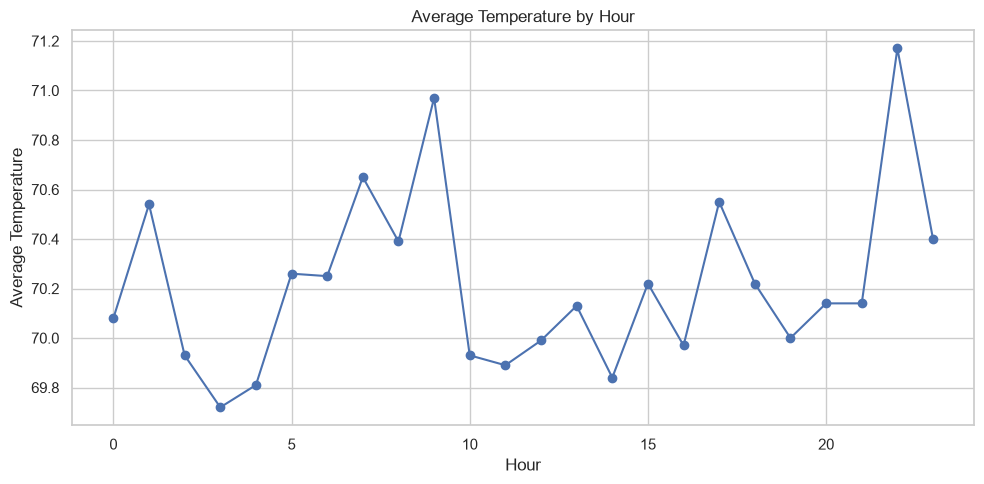

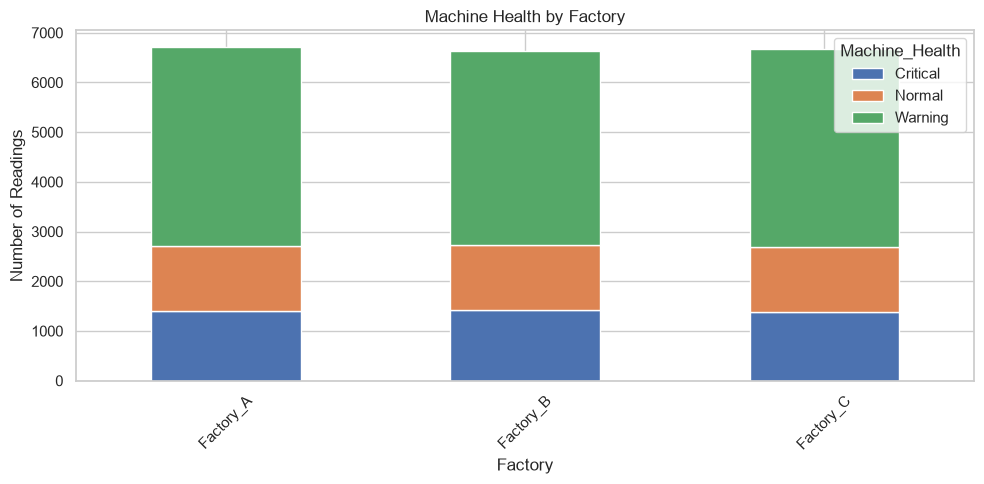

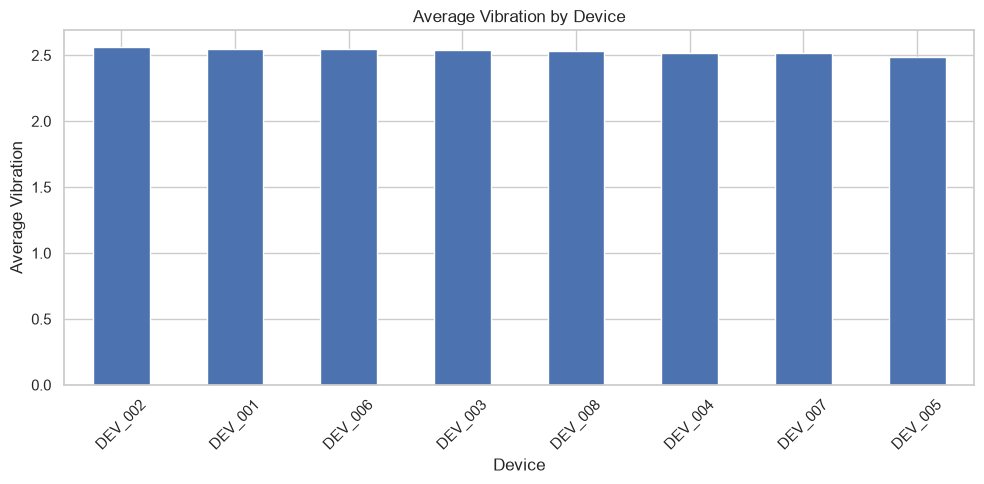

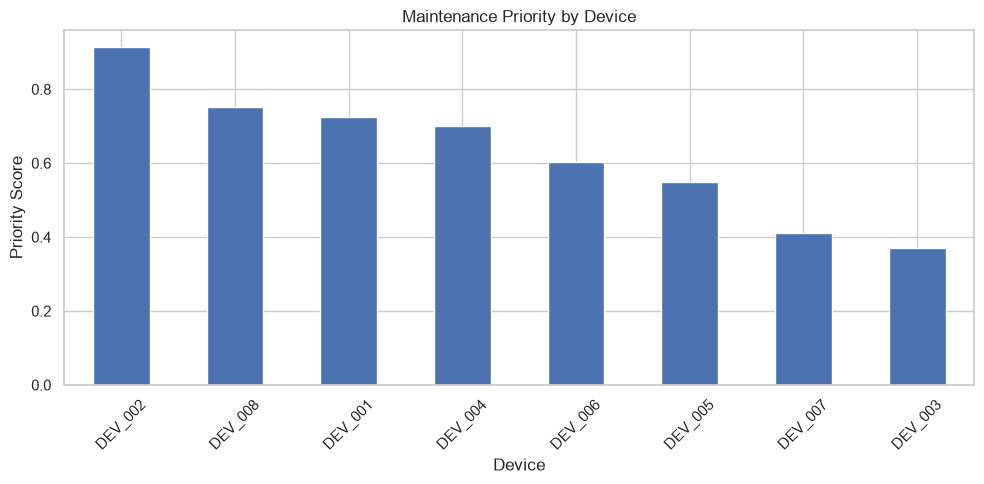

In [7]:
sns.set_theme(style="whitegrid")

# Average temperature by hour
plt.figure(figsize=(10, 5))
average_temperature_by_hour.plot(kind="line", marker="o")
plt.title("Average Temperature by Hour")
plt.xlabel("Hour")
plt.ylabel("Average Temperature")
plt.tight_layout()
plt.savefig(OUTPUT / "average_temperature_by_hour.png", dpi=150)
plt.show()
plt.close()

# Machine health by factory
plt.figure(figsize=(10, 5))
health_factory = pd.crosstab(df["Location"], df["Machine_Health"])
health_factory.plot(kind="bar", stacked=True, ax=plt.gca())
plt.title("Machine Health by Factory")
plt.xlabel("Factory")
plt.ylabel("Number of Readings")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(OUTPUT / "machine_health_by_factory.png", dpi=150)
plt.show()
plt.close()

# Average vibration by device
plt.figure(figsize=(10, 5))
device_averages["Average_Vibration"].sort_values(ascending=False).plot(kind="bar")
plt.title("Average Vibration by Device")
plt.xlabel("Device")
plt.ylabel("Average Vibration")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(OUTPUT / "average_vibration_by_device.png", dpi=150)
plt.show()
plt.close()

# Maintenance priority
plt.figure(figsize=(10, 5))
maintenance["Maintenance_Priority_Score"].plot(kind="bar")
plt.title("Maintenance Priority by Device")
plt.xlabel("Device")
plt.ylabel("Priority Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(OUTPUT / "maintenance_priority_by_device.png", dpi=150)
plt.show()
plt.close()

## Save Cleaned Dataset

In [8]:
cleaned_file = OUTPUT / "iot_sensor_data_cleaned.csv"
df.to_csv(cleaned_file, index=False)
print("Cleaned dataset saved to:", cleaned_file)

Cleaned dataset saved to: d:\IIT-M\Day 4\Assignment 3\output\iot_sensor_data_cleaned.csv
